In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


def find_nearest_cluster(embedding, centers):
    def get_distance2d(embedding, center):
        distance = np.sqrt(np.pow(embedding[0] - center[0], 2) + np.pow(embedding[1] - center[1], 2))
        return distance

    nearest_center_idx = None
    best_distance = float("inf")
    for i, center in enumerate(centers):
        new_distance = get_distance2d(embedding, center)
        if new_distance < best_distance:
            nearest_center_idx = i
            best_distance = new_distance
    
    return nearest_center_idx


def vq_quantize(embeddings, centers):
    # for all embeddings, return:
    # - the quantized embeddings (replaced by their nearest center)
    # - the indices of the nearest centers
    # - the residuals (original - quantized)

    nearest_centers_idx = []
    quantized_embeddings = []
    residuals = []
    for embedding in embeddings:
        nearest_cluster_idx = find_nearest_cluster(embedding, centers)
        quantized_embedding = centers[nearest_cluster_idx]
        residual = embedding - quantized_embedding
        nearest_centers_idx.append(nearest_cluster_idx)
        quantized_embeddings.append(quantized_embedding)
        residuals.append(residual)

    return nearest_centers_idx, quantized_embeddings, residuals


def rvq_quantize(embeddings, n_levels, n_clusters=8):
    residual = np.array(embeddings)
    all_indices = []
    all_residuals = []
    all_centers = []

    for level in range(n_levels):
        kmeans = KMeans(n_clusters=n_clusters, random_state=level, n_init="auto").fit(residual)
        centers = kmeans.cluster_centers_
        indices, quantized, new_residuals = vq_quantize(residual, centers)
        all_indices.append(np.array(indices))
        all_residuals.append(residual)
        all_centers.append(centers)
        residual = np.array(new_residuals)

    return all_indices, all_residuals, all_centers

In [2]:
# 1. Generate some random 2D embeddings (pretend these are encoder outputs)
embeddings = np.vstack([
    np.random.randn(25, 2) + center 
    for center in np.random.randn(8, 2) * 3
])

# 2. Settings
n_clusters = 8
n_levels = 8

# RVQ
all_indices, all_residuals, all_centers = rvq_quantize(embeddings, 8, n_clusters=8)

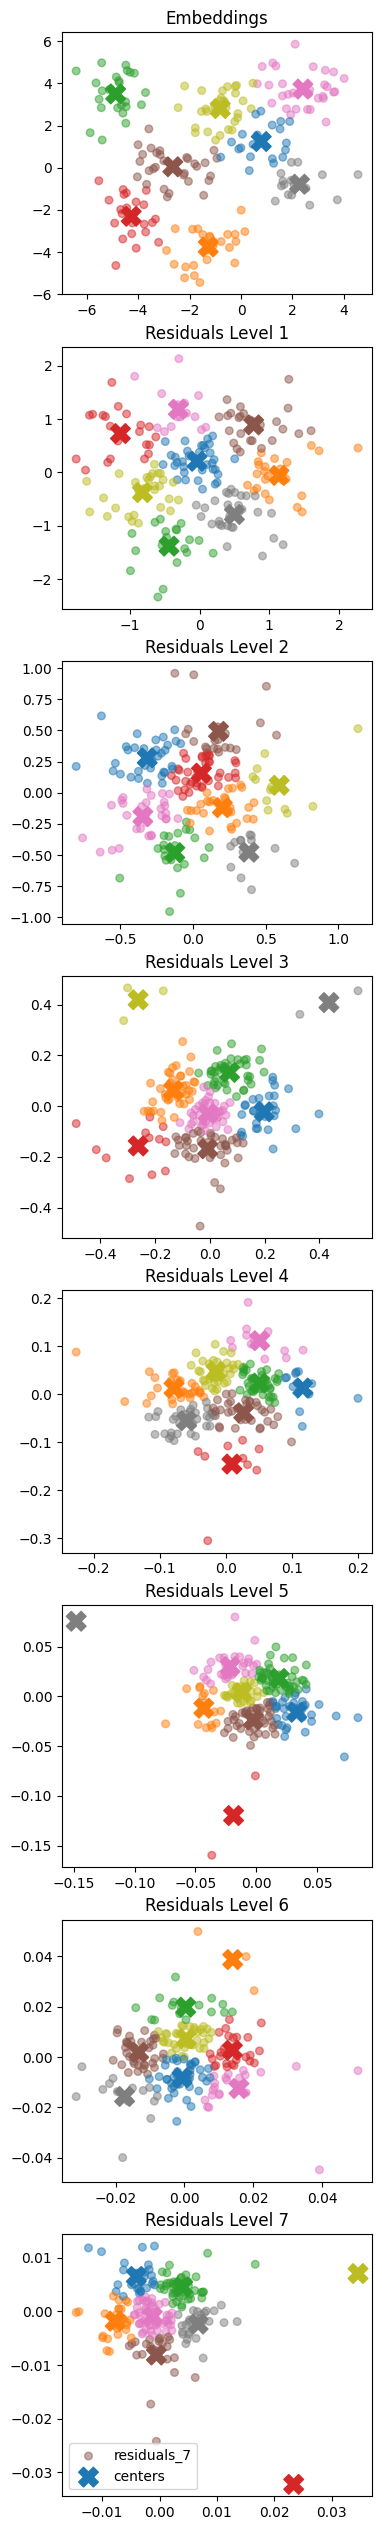

In [3]:
# Plot
fig, axes = plt.subplots(8, 1 , figsize=(4, 4 * 8))

for i, (axis, residuals, indices, centers) in enumerate(zip(axes, all_residuals, all_indices, all_centers)):
    colors = plt.cm.tab10(indices / n_clusters)
    center_colors = plt.cm.tab10(np.arange(n_clusters) / n_clusters)
    axis.scatter(
        residuals[:, 0], 
        residuals[:, 1], 
        c=colors, 
        alpha=0.5, 
        s=30, 
        label=f"embedding" if i == 0 else f"residuals_{i}"
    )
    axis.scatter(
        centers[:, 0], 
        centers[:, 1], 
        c=center_colors, 
        marker="X", 
        s=200, 
        zorder=5, 
        label="centers"
    )
    if i == 0:
        axis.set_title("Embeddings")
    else:
        axis.set_title(f"Residuals Level {i}")

plt.legend()
plt.show()